# Modeling Ideal Prototypes and Imperfect Instances:
## A Mathematical Interpretation of Plato’s Theory of Forms

Author: Ivan Goranov  
Course: Math for Developers  
Date: 2026

### Introduction
Plato’s Theory of Forms proposes that the physical world is not the ultimate reality, but rather a representation of ideal and abstract entities called Forms. Physical objects are imperfect imitations of these ideal Forms. The Forms themselves are eternal, perfect, and independent of human perception.

This project does not attempt to prove the metaphysical existence of Forms. Instead, it models the concept mathematically by representing a Form as an ideal prototype in a vector space. Imperfect instances are generated as variations of this prototype, and their deviation from the ideal is quantified using Euclidean distance. The project further explores whether the original prototype can be estimated from many imperfect instances using their mean.

### Hypothesis

If imperfect instances are generated as noisy variations around an ideal prototype (Platonic Form), then:

1. The Euclidean distance can quantify the degree of imperfection of each instance.
2. The mean of multiple imperfect instances will approximate the ideal prototype.

This models Plato's idea that physical instances are imperfect copies of ideal Forms.

### Mathematical Model

In this project, we represent the Platonic Form as an ideal prototype vector in a 2-dimensional space:

$$
\vec{v}^* = \begin{bmatrix} v_1^* \\ v_2^* \end{bmatrix}
$$

Here, $\vec{v}^*$ represents the perfect Form, modeled as a fixed point in $\mathbb{R}^2$.

Each imperfect instance contains the ideal prototype within itself and is generated as a noisy variation of it:

$$
\vec{v}_i = \vec{v}^* + \vec{\varepsilon}_i
$$

where $\vec{\varepsilon}_i$ is a random noise vector representing deviation from the ideal Form.

The degree of imperfection of an instance is measured by the Euclidean distance between the instance and the prototype:

$$
d_i = \sqrt{(v_{i1} - v_1^*)^2 + (v_{i2} - v_2^*)^2}
$$

This distance quantifies how far an imperfect instance lies from the ideal Form.

Finally, we estimate the ideal prototype from multiple imperfect instances using the mean:

$$
\hat{\vec{v}}^* = \frac{1}{n} \sum_{i=1}^{n} \vec{v}_i
$$

We then compare $\hat{\vec{v}}^*$ to the original $\vec{v}^*$ to evaluate how well the mean of imperfect instances approximates the ideal Form.

### Implementation
A two-dimensional space is used so that imperfect instances can deviate from the prototype in multiple directions. This allows clearer visualization and more meaningful measurement of Euclidean distance between the ideal Form and its imperfect copies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

##### Ideal Prototype

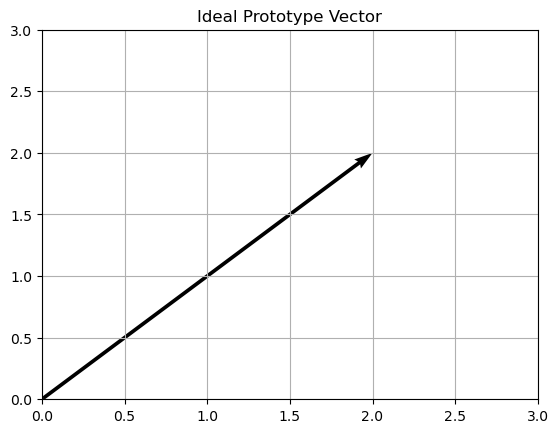

In [2]:
v_form = np.array([2, 2])

plt.quiver(0, 0, v_form[0], v_form[1], angles='xy', scale_units='xy', scale=1)
plt.title("Ideal Prototype Vector")
plt.xlim(0, 3)
plt.ylim(0, 3)
plt.grid()
plt.show()

##### Imperfect Instances: 
The noise is generated using Gaussian noise with mean 0 so that imperfections do not systematically shift the instances away from the ideal Form. This ensures that, on average, imperfect copies still reflect the underlying prototype.

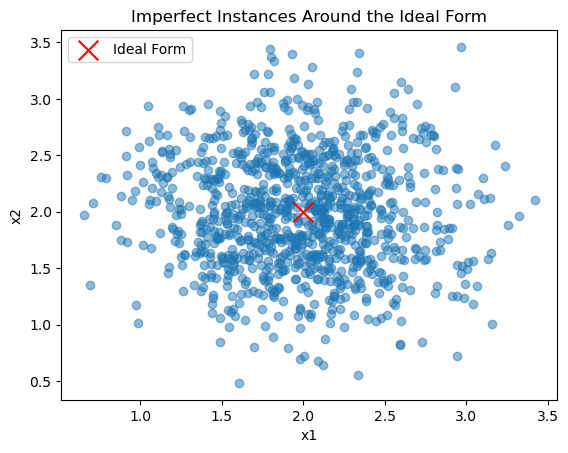

In [8]:
n_samples = 1000

noise = np.random.normal(0, 0.5, (n_samples, 2))
instances = v_form + noise

plt.scatter(instances[:,0], instances[:,1], alpha=0.5)
plt.scatter(v_form[0], v_form[1], color='red', marker='x', s=200, label='Ideal Form')

plt.title("Imperfect Instances Around the Ideal Form")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()



##### Measuring Imperfection: Euclidean Distance
The degree of imperfection of an instance can be measured as the Euclidean distance between the instance and the ideal prototype using numpy.linalg.norm. Larger distances correspond to greater deviations from the Form.

Average imperfection: 0.6354316620740624
Maximum imperfection: 1.82428593368027
Minimum imperfection: 0.005271532813343476


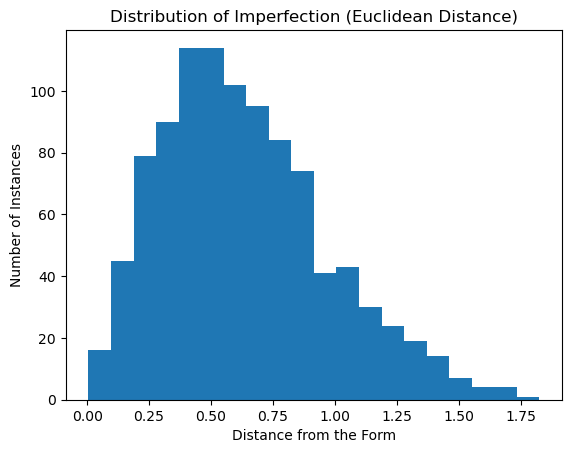

In [4]:
distances = np.linalg.norm(instances - v_form, axis=1)

print("Average imperfection:", np.mean(distances))
print("Maximum imperfection:", np.max(distances))
print("Minimum imperfection:", np.min(distances))

plt.hist(distances, bins=20)
plt.title("Distribution of Imperfection (Euclidean Distance)")
plt.xlabel("Distance from the Form")
plt.ylabel("Number of Instances")
plt.show()

The average imperfection remains relatively stable when increasing the number of samples. This is expected because the average distance from the Form depends mainly on the variance of the noise distribution rather than the number of instances.

##### Estimating the Ideal Form Using the Mean
The ideal Form can be estimated by averaging all generated instances. Because the noise added to the instances has a mean of zero, positive and negative deviations tend to cancel out. As a result, the mean vector is close to the original prototype vector.

In [5]:
estimated_form = np.mean(instances, axis=0)
error = np.linalg.norm(estimated_form - v_form)

print(f"Estimated Form: {estimated_form}")
print(f"True Form: {v_form}")
print(f"Estimation Error: {error}")

Estimated Form: [2.00510249 1.98382895]
True Form: [2 2]
Estimation Error: 0.016956953038117402


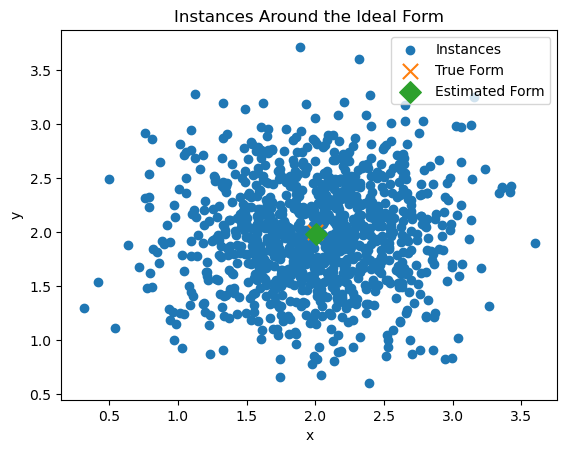

In [6]:
plt.scatter(instances[:,0], instances[:,1], label="Instances")
plt.scatter(v_form[0], v_form[1], marker='x', s=120, label="True Form")
plt.scatter(estimated_form[0], estimated_form[1], marker='D', s=120, label="Estimated Form")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Instances Around the Ideal Form")
plt.legend()
plt.show()

### Experiment: The Law of Large Numbers
In probability theory, the law of large numbers is a mathematical law that states that the average of the results obtained from a large number of independent random samples converges to the true value, if it exists. In this experiment we will use try to find out whether we will get closer to the true Form by increasing the sample size.

In [24]:
sample_sizes = [5, 20, 100, 1000, 10000]

for n in sample_sizes:
    instances = v_form + np.random.normal(0, 0.5, (n, 2))
    estimated = np.mean(instances, axis=0)
    distance = np.linalg.norm(estimated - v_form, axis=0)
    print(f"n = {n}, estimated form = {estimated}, difference = {distance}")

n = 5, estimated form = [1.78084496 2.30230462], difference = 0.3733858769358673
n = 20, estimated form = [2.09945054 2.2678787 ], difference = 0.28574360547152133
n = 100, estimated form = [1.95653682 2.03181793], difference = 0.053864909587592005
n = 1000, estimated form = [1.99569871 1.99016855], difference = 0.01073119189894798
n = 10000, estimated form = [1.99908891 1.99693542], difference = 0.003197149452405187


The experiment shows that as the number of samples increases, the sample mean converges toward the true mean.
